In [77]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# Dataset
# -------------------------

# Study Method
# Online  -> [1, 0, 0]
# Offline -> [0, 1, 0]
# Hybrid  -> [0, 0, 1]

# One-Hot Encoding
study_method = torch.tensor([
    [1, 0, 0],   # Online
    [0, 1, 0],   # Offline
    [1, 0, 0],   # Online
    [0, 1, 0],   # Offline
    [0, 0, 1],   # Hybrid
    [1, 0, 0],   # Online
    [0, 0, 1],   # Hybrid
    [0, 1, 0]    # Offline
], dtype=torch.float32)

study_method_embedding = nn.Embedding(
    num_embeddings = 3,
    embedding_dim= 2
)

# 3 categories
#      ↓
# each category gets
#      ↓
# a 2-dimensional vector

# Online 1
# Offline 2
# Hybrid 3

methods = torch.tensor([1,2,1,2,3,1,3,2])
methods_output = study_method_embedding(methods)



# Sleep
# Poor = 0
# Good = 1

sleep = torch.tensor([
    [1],
    [0],
    [1],
    [1],
    [0],
    [1],
    [0],
    [0]
], dtype=torch.float32)

# Attendance
attendance = torch.tensor([
    [90],
    [55],
    [85],
    [75],
    [60],
    [95],
    [65],
    [50]
], dtype=torch.float32)

attendance_n = (attendance - attendance.mean()) / attendance.std()
mean = attendance.mean()
std = attendance.std()


# Target
# Fail = 0
# Pass = 1

y_real = torch.tensor([
    [1],
    [0],
    [1],
    [1],
    [0],
    [1],
    [0],
    [0]hjb
], dtype=torch.float32)




SyntaxError: invalid syntax. Perhaps you forgot a comma? (3218596269.py, line 94)

In [75]:
from torch.utils.data import TensorDataset
X = torch.cat([methods_output, sleep, attendance_n], dim = 1)

ds = TensorDataset(X, y_real)
print(ds[0])

NameError: name 'methods_output' is not defined

In [58]:
from torch.utils.data import DataLoader
loader = DataLoader(
    ds,
    batch_size = 2,
    shuffle=True
)

In [59]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.Layer1 = nn.Linear(5, 8)
        self.Layer2 = nn.Linear(8, 4)
        self.Layer3 = nn.Linear(4, 1)

        self.activationfn = nn.ReLU();

    def forward(self, x):
        x = self.Layer1(x)
        x = self.activationfn(x)

        x = self.Layer2(x)
        x = self.activationfn(x)

        x = self.Layer3(x)

        return x

In [67]:
model = MyModel()
loss_fn = nn.MSELoss()
loss_history = []
loss = torch.tensor(float("inf"))
optimiser = optim.Adam(model.parameters(), 0.1)

In [68]:
accuracy = 0.01
epoachs = 20
i = 0
j = 0
while loss.item() > accuracy:

    if i >= epoachs:
        break
    for X_sample, y_sample in loader:

        # Reset Gradients
        optimiser.zero_grad()

        # Forward Pass
        y_pred = model(X_sample)

        # loss
        loss = loss_fn(y_pred, y_sample)
        loss_history.append(loss.item())

        # Backward
        loss.backward()

        # Change Weights and biases
        optimiser.step()

        # For Seaborn
        j += 1

    i += 1
    print(f"Traversal {i} : loss = {loss.item()}")



Traversal 1 : loss = 0.2766265273094177
Traversal 2 : loss = 0.04777274280786514
Traversal 3 : loss = 0.5782964825630188
Traversal 4 : loss = 0.4652930200099945
Traversal 5 : loss = 0.5161600112915039
Traversal 6 : loss = 0.2782433331012726
Traversal 7 : loss = 0.7725124359130859
Traversal 8 : loss = 0.07987552136182785
Traversal 9 : loss = 0.07997121661901474
Traversal 10 : loss = 0.11319741606712341
Traversal 11 : loss = 0.27443042397499084
Traversal 12 : loss = 0.27743983268737793
Traversal 13 : loss = 0.006393994204699993


In [62]:
def predictVal(method, sleep, attendance):
    sleep_n = 1 if sleep == "Good" else 0
    attendance_n = (attendance - mean) / std
    if method.lower() == "online":
        method_n = [1, 0, 0]
    elif method.lower() == "offline":
        method_n = [0, 1, 0]
    else:
        method_n = [0, 0, 1]

    data = torch.tensor(
        [method_n + [sleep_n, attendance_n]],
        dtype=torch.float32
    )
    return round(model(data).item())



In [69]:
predictVal("online", "Good", 100)

0

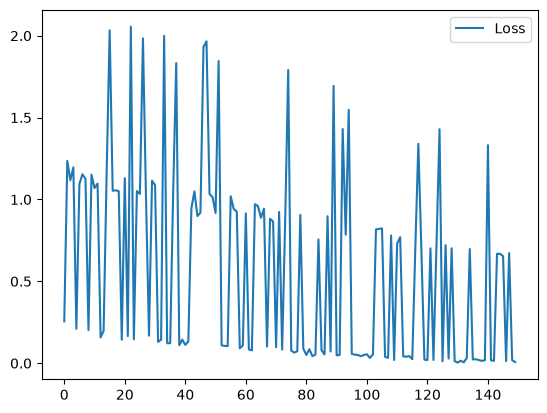

In [64]:
# Visualising Loss overtime
sns.lineplot(
    x = list(range(j)),
    y = loss_history,
    label = "Loss"
)

plt.show()